# E-commerce Reviews — Sentiment ML Baselines

A reproducible baseline experiment following the shared 25-section assignment workflow.

## 01. Problem Definition

Infer Negative, Neutral, or Positive sentiment from review text and compare three classical classifiers.

## 02. Import Libraries

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 03. Experiment Configuration

In [2]:
EXPERIMENT_NAME="ml_baseline"; TEXT_COL="Review Text"; RATING_COL="Rating"; TARGET="sentiment"
SELECTED_FEATURES=[TEXT_COL]; BEST_METRIC="Macro F1"

## 04. Paths

In [3]:
PROJECT_DIR=Path.cwd()
if not (PROJECT_DIR/"data"/"Womens Clothing E-Commerce Reviews.csv").exists(): PROJECT_DIR=Path("project/e-commerce-comment-analytis")
DATA_DIR,FIGURE_DIR,MODEL_DIR,OUTPUT_DIR=(PROJECT_DIR/x for x in ("data","figures","models","outputs"))
for directory in (FIGURE_DIR,MODEL_DIR,OUTPUT_DIR): directory.mkdir(parents=True,exist_ok=True)
print("Project directory:",PROJECT_DIR.resolve())

Project directory: D:\Nam_4\ki_1\HTTM\Assign_03\project\e-commerce-comment-analytis


## 05. Load Dataset

In [4]:
df=pd.read_csv(DATA_DIR/"Womens Clothing E-Commerce Reviews.csv"); print("Shape:",df.shape); display(df.head())

Shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 06. Data Understanding

In [5]:
df.info(); display(df.describe(include="all").T); print("Missing review text:",int(df[TEXT_COL].isna().sum())); print("Duplicate review texts:",int(df[TEXT_COL].duplicated().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,NaN,NaN,NaN,11742.5,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing review text: 845
Duplicate review texts: 851


## 07. Data Cleaning

In [6]:
df=df.dropna(subset=[TEXT_COL,RATING_COL]).drop_duplicates(subset=[TEXT_COL]).copy(); df[TEXT_COL]=df[TEXT_COL].astype(str).str.strip(); df=df[df[TEXT_COL].str.len()>0]
print("Clean rows:",len(df))

Clean rows: 22634


## 08. Feature Engineering

Rating creates the research label only and is deliberately excluded from model inputs to prevent target leakage.

In [7]:
df[TARGET]=pd.cut(df[RATING_COL],bins=[0,2,3,5],labels=["Negative","Neutral","Positive"])
df["Review Length"]=df[TEXT_COL].str.len(); df["Word Count"]=df[TEXT_COL].str.split().str.len()

## 09. Feature Selection

Selected input: ['Review Text']


,count
sentiment,
Positive,17442
Neutral,2823
Negative,2369


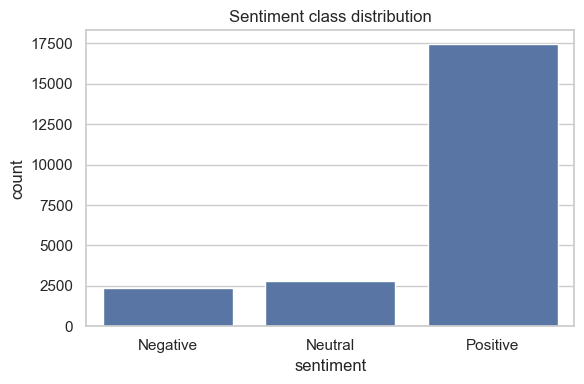

In [8]:
X=df[TEXT_COL].copy(); y=df[TARGET].astype(str); print("Selected input:",SELECTED_FEATURES); display(y.value_counts().to_frame("count"))
plt.figure(figsize=(6,4)); sns.countplot(x=y,order=["Negative","Neutral","Positive"]); plt.title("Sentiment class distribution"); plt.tight_layout(); plt.savefig(FIGURE_DIR/"class_distribution.png",dpi=160); plt.show()

## 10. Train/Test Split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=RANDOM_STATE,stratify=y); print("Train:",len(X_train),"Test:",len(X_test))

Train: 18107 Test: 4527


## 11. Preprocessing

In [10]:
def make_tfidf(): return TfidfVectorizer(max_features=12000,ngram_range=(1,2),min_df=2,sublinear_tf=True,strip_accents="unicode")

## 12. Define 3 ML Models

In [11]:
models={
 "Logistic Regression":Pipeline([("tfidf",make_tfidf()),("model",LogisticRegression(max_iter=1000,class_weight="balanced",random_state=RANDOM_STATE))]),
 "Decision Tree":Pipeline([("tfidf",make_tfidf()),("model",DecisionTreeClassifier(max_depth=40,min_samples_leaf=4,class_weight="balanced",random_state=RANDOM_STATE))]),
 "Random Forest":Pipeline([("tfidf",make_tfidf()),("model",RandomForestClassifier(n_estimators=120,max_depth=50,min_samples_leaf=2,class_weight="balanced_subsample",n_jobs=-1,random_state=RANDOM_STATE))]),
}
model_files={"Logistic Regression":"logistic_regression.joblib","Decision Tree":"decision_tree.joblib","Random Forest":"random_forest.joblib"}

## 13. Train Models

In [12]:
predictions={}
for name,model in models.items(): model.fit(X_train,y_train); predictions[name]=model.predict(X_test); print("Trained:",name)

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


## 14. Evaluation Metrics

In [13]:
rows=[]
for name,pred in predictions.items():
    rows.append({"Model":name,"Accuracy":accuracy_score(y_test,pred),"Weighted Precision":precision_score(y_test,pred,average="weighted",zero_division=0),"Weighted Recall":recall_score(y_test,pred,average="weighted",zero_division=0),"Weighted F1":f1_score(y_test,pred,average="weighted",zero_division=0),"Macro F1":f1_score(y_test,pred,average="macro",zero_division=0)})

## 15. Model Comparison Table

In [14]:
results=pd.DataFrame(rows).sort_values("Macro F1",ascending=False).reset_index(drop=True); display(results.style.format({c:"{:.4f}" for c in results.columns if c!="Model"}))

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
0,Logistic Regression,0.7901,0.8309,0.7901,0.8067,0.6213
1,Random Forest,0.8105,0.7747,0.8105,0.7851,0.5501
2,Decision Tree,0.6256,0.7378,0.6256,0.6672,0.4539


## 16. Visualization

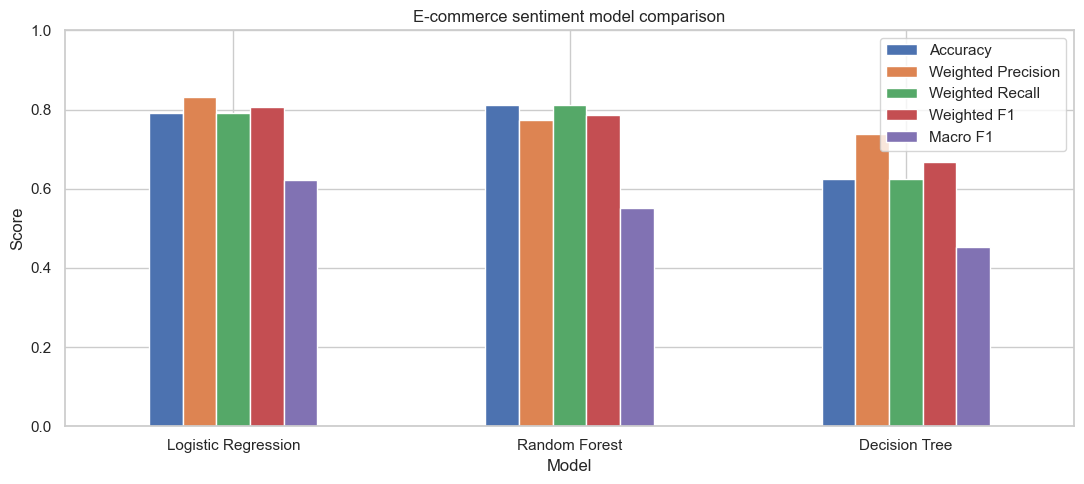

In [15]:
results.set_index("Model").plot(kind="bar",figsize=(11,5),ylim=(0,1),rot=0); plt.ylabel("Score"); plt.title("E-commerce sentiment model comparison"); plt.tight_layout(); plt.savefig(FIGURE_DIR/"ml_model_comparison.png",dpi=160); plt.show()

## 17. Select Best Model

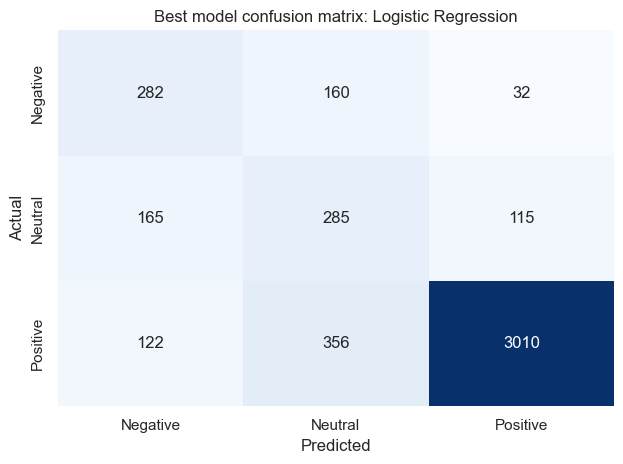

Best model by Macro F1: Logistic Regression


In [16]:
best_name=results.iloc[0]["Model"]; best_model=models[best_name]; labels=["Negative","Neutral","Positive"]
cm=confusion_matrix(y_test,predictions[best_name],labels=labels); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=labels,yticklabels=labels,cbar=False); plt.title(f"Best model confusion matrix: {best_name}"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(FIGURE_DIR/"best_confusion_matrix.png",dpi=160); plt.show(); print("Best model by Macro F1:",best_name)

## 18. Save 3 Models

In [17]:
model_paths={}
for name,model in models.items(): path=MODEL_DIR/model_files[name]; joblib.dump(model,path); model_paths[name]=path

## 19. Save Best Model

In [18]:
best_path=MODEL_DIR/"best_ecommerce_model.joblib"; joblib.dump(best_model,best_path)

['D:\\Nam_4\\ki_1\\HTTM\\Assign_03\\project\\e-commerce-comment-analytis\\models\\best_ecommerce_model.joblib']

## 20. Save Results

In [19]:
results.to_csv(OUTPUT_DIR/"ecommerce_ml_results.csv",index=False)

## 21. Save Feature/Config

In [20]:
config={"experiment":EXPERIMENT_NAME,"task":"multiclass_text_classification","target":TARGET,"target_definition":{"1-2":"Negative","3":"Neutral","4-5":"Positive"},"features":SELECTED_FEATURES,"excluded_to_prevent_leakage":[RATING_COL],"models":list(models),"best_metric":BEST_METRIC,"best_model":best_name,"random_state":RANDOM_STATE}
with open(OUTPUT_DIR/"model_config.json","w",encoding="utf-8") as f: json.dump(config,f,indent=2,ensure_ascii=False)

## 22. Reload 3 Models

In [21]:
loaded_models={name:joblib.load(path) for name,path in model_paths.items()}

## 23. Predict Test Sample

In [22]:
sample=X_test.iloc[[0]]; actual=y_test.iloc[0]; verification=pd.DataFrame([{"Model":name,"Prediction":model.predict(sample)[0],"Actual":actual} for name,model in loaded_models.items()]); display(sample.to_frame("Review Text")); display(verification)

,Review Text
10878,"I love, love this top! it's the perfect peplum..."


,Model,Prediction,Actual
0,Logistic Regression,Positive,Positive
1,Decision Tree,Neutral,Positive
2,Random Forest,Positive,Positive


## 24. Verify Saved Models

In [23]:
for name in models: np.testing.assert_array_equal(loaded_models[name].predict(sample),models[name].predict(sample))
assert joblib.load(best_path).predict(sample).shape==(1,); print("[OK] All saved models loaded and predicted successfully.")

[OK] All saved models loaded and predicted successfully.


## 25. Conclusion

In [24]:
print(f"Best model: {best_name} | Macro F1={results.iloc[0]['Macro F1']:.4f} | Accuracy={results.iloc[0]['Accuracy']:.4f}")
print("Each saved pipeline contains both TF-IDF and its classifier, ready for inference on raw review text.")

Best model: Logistic Regression | Macro F1=0.6213 | Accuracy=0.7901
Each saved pipeline contains both TF-IDF and its classifier, ready for inference on raw review text.
